# 04.2 XGBoost Root-Cause Sensitivity

Notebook 04 explains the selected `random_forest` model. This companion notebook asks a narrower robustness question: because XGBoost was close to random forest in cross-validated PR-AUC, do the leading sensor rankings hold if explanations are generated from the near-tie XGBoost model instead?

The selected production artifact remains `models/selected_model.joblib`; this notebook is a robustness check on the sensor ranking, not a second model-selection step.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)

sys.path.insert(0, str(ROOT / "src"))

from yield_risk.config import load_config
from yield_risk.explainability import (
    compute_shap_values,
    global_feature_importance,
)
from yield_risk.root_cause import (
    fail_shap_lift,
    rank_root_cause_candidates,
    spc_flag_rate,
)

pd.set_option("display.max_colwidth", 120)

In [2]:
cfg = load_config(ROOT / "configs" / "config.yaml")
reports_dir = cfg.paths.reports_dir
models_dir = cfg.paths.models_dir

train = pd.read_csv(cfg.paths.splits_dir / "train.csv")
test = pd.read_csv(cfg.paths.splits_dir / "test.csv")
sensor_cols = [c for c in test.columns if c.startswith("sensor_")]

X_train = train[sensor_cols]
X_test = test[sensor_cols]
y_test = test["label"].to_numpy()

rf_candidates = pd.read_csv(reports_dir / "root_cause_candidates.csv")
rf_global = pd.read_csv(reports_dir / "shap_global_importance.csv")
xgb_pipeline = joblib.load(models_dir / "xgboost.joblib")

print(f"Loaded {len(X_train):,} train rows and {len(X_test):,} test rows.")
print(f"Loaded XGBoost model from {models_dir / 'xgboost.joblib'}")
print(f"Selected-model root-cause baseline: {reports_dir / 'root_cause_candidates.csv'}")

Loaded 1,331 train rows and 236 test rows.
Loaded XGBoost model from models\xgboost.joblib
Selected-model root-cause baseline: reports\root_cause_candidates.csv


## Method

The sensitivity path mirrors notebook 04 exactly, except the fitted model is `models/xgboost.joblib` rather than the selected random-forest artifact. The comparison uses the same processed test rows, the same SHAP utility, the same fail/pass SHAP lift calculation, and the same SPC flag-rate calculation.

Background dataset has 1331 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1331 when initializing the masker.


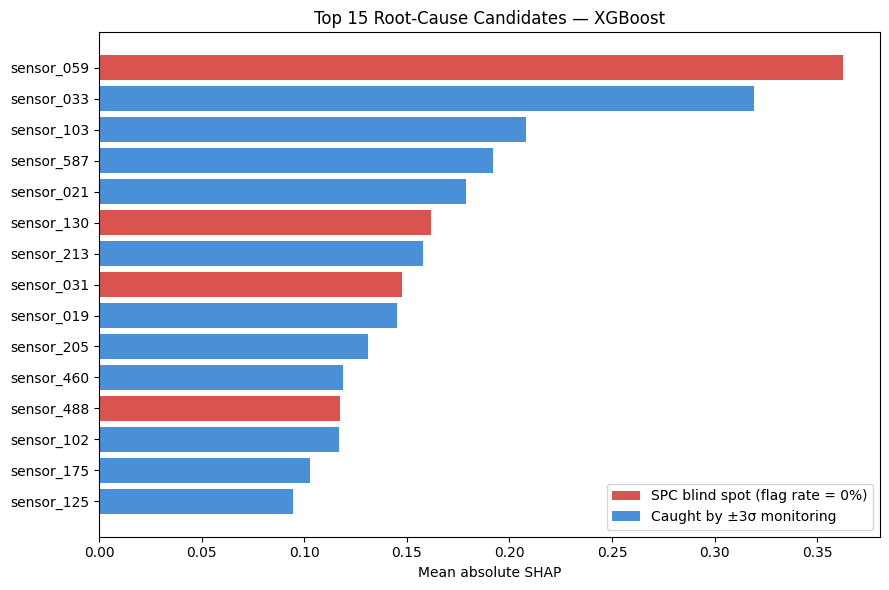

In [3]:
xgb_explanations = compute_shap_values(xgb_pipeline, X_train, X_test)
xgb_global = global_feature_importance(xgb_explanations)
xgb_lift = fail_shap_lift(xgb_explanations, y_test)
train_pass = train[train["label"] == 0]
flag_rates = spc_flag_rate(test, sensor_cols, reference=train_pass)
xgb_candidates = rank_root_cause_candidates(xgb_global, xgb_lift, flag_rates)

top = xgb_candidates.head(15).sort_values("mean_abs_shap")
colors = ["#d9534f" if v == 0.0 else "#4a90d9" for v in top["spc_flag_rate"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["sensor"], top["mean_abs_shap"], color=colors)
ax.set_xlabel("Mean absolute SHAP")
ax.set_title("Top 15 Root-Cause Candidates — XGBoost")
ax.legend(
    handles=[
        Patch(facecolor="#d9534f", label="SPC blind spot (flag rate = 0%)"),
        Patch(facecolor="#4a90d9", label="Caught by ±3σ monitoring"),
    ],
    loc="lower right",
)
plt.tight_layout()
plt.show()

## Ranking Overlap

A sensor ranking is more robust when a near-tie model family surfaces many of the same leading sensors.

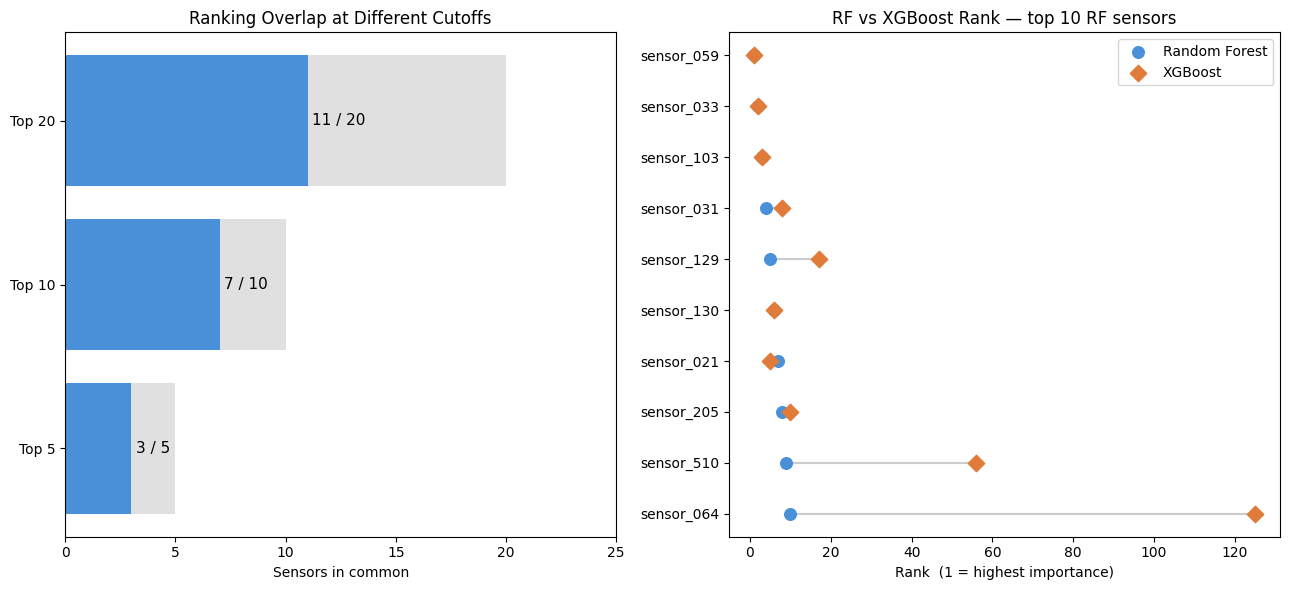

In [4]:
def top_sensor_set(df: pd.DataFrame, n: int) -> set[str]:
    """Return the top-n sensor names from a root-cause candidate table."""
    return set(df.head(n)["sensor"].tolist())


summary_rows = []
for n in (5, 10, 20):
    rf_top = top_sensor_set(rf_candidates, n)
    xgb_top = top_sensor_set(xgb_candidates, n)
    overlap = rf_top & xgb_top
    union = rf_top | xgb_top
    summary_rows.append({"top_n": n, "overlap_count": len(overlap), "jaccard": len(overlap) / len(union)})
sensitivity_summary = pd.DataFrame(summary_rows)

rf_ranked = rf_candidates.copy()
rf_ranked["rf_rank"] = range(1, len(rf_ranked) + 1)
xgb_ranked = xgb_candidates.copy()
xgb_ranked["xgb_rank"] = range(1, len(xgb_ranked) + 1)

top10 = (
    rf_ranked.head(10)[["sensor", "rf_rank"]]
    .merge(xgb_ranked[["sensor", "xgb_rank"]], on="sensor", how="left")
    .sort_values("rf_rank", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Left: overlap bar chart
ax = axes[0]
ns = [r["top_n"] for r in summary_rows]
counts = [r["overlap_count"] for r in summary_rows]
ax.barh([f"Top {n}" for n in ns], ns, color="#e0e0e0")
ax.barh([f"Top {n}" for n in ns], counts, color="#4a90d9")
for i, (c, n) in enumerate(zip(counts, ns)):
    ax.text(c + 0.2, i, f"{c} / {n}", va="center", fontsize=11)
ax.set_xlabel("Sensors in common")
ax.set_title("Ranking Overlap at Different Cutoffs")
ax.set_xlim(0, 25)

# Right: rank comparison dot plot
ax = axes[1]
ys = list(range(len(top10)))
for i, row in enumerate(top10.itertuples()):
    ax.plot([row.rf_rank, row.xgb_rank], [i, i], color="#cccccc", lw=1.5, zorder=1)
ax.scatter(top10["rf_rank"], ys, color="#4a90d9", zorder=2, label="Random Forest", s=70)
ax.scatter(top10["xgb_rank"], ys, color="#e07b39", zorder=2, label="XGBoost", s=70, marker="D")
ax.set_yticks(ys)
ax.set_yticklabels(top10["sensor"].tolist())
ax.set_xlabel("Rank  (1 = highest importance)")
ax.set_title("RF vs XGBoost Rank — top 10 RF sensors")
ax.legend()

plt.tight_layout()
plt.show()

The left panel shows how many sensors both models agree on at different cutoffs. At the top five, three of five are shared; by the top ten, seven of ten overlap. The agreement is strongest where it matters most — the leading candidates.

The right panel shows where each of the top ten RF sensors lands in XGBoost. Short connecting lines indicate stable sensors; long lines indicate sensors one model values and the other does not. `sensor_059`, `sensor_033`, and `sensor_103` sit at ranks 1, 2, and 3 under both models — the lines are nearly invisible because there is no movement. `sensor_129` drops from RF rank 5 to XGBoost rank 17, and `sensor_064` falls from RF rank 10 to XGBoost rank 125 — both sensors are RF-specific signals that XGBoost does not emphasize.

The stable top three are the sensors to act on first. The sensors with long lines are worth noting but should not drive engineering follow-up until their ranking is validated by process context.